# Hindcast vs Buoy Storm Matching and Validation

# Objective of Storm Matching
Objective

The objective of this section is to assess the accuracy of the NZ Wave Hindcast in representing real storm events observed by the ECAN wave buoy.

We evaluate whether the hindcast:

Detects the same storms

Accurately reproduces storm timing

Represents storm intensity and duration

This forms the foundation of wave model validation, a critical step in coastal erosion studies.

# Load Cleaned ECAN and Hindcast Datasets

We load the cleaned datasets to ensure consistency and reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ecan_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\ECAN_wave_buoy_CLEANED.csv"
hindcast_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\Nz_Hindcast_clean.csv"

ecan = pd.read_csv(ecan_path, parse_dates=["datetime"])
hindcast = pd.read_csv(hindcast_path, parse_dates=["datetime"])

ecan = ecan.sort_values("datetime").reset_index(drop=True)
hindcast = hindcast.sort_values("datetime").reset_index(drop=True)

# Storm Definition Consistency
Why This Matters

To ensure a fair comparison, both datasets must use the same storm definition:

Hs > 2.5 m

Minimum storm duration: 3 days (72 hours)

Minimum storm separation: 24 hours

We therefore re-extract storm events consistently from both datasets.

# Function to Extract Storm Events

To avoid duplication and ensure consistency, we define a reusable storm extraction function.

In [3]:
def extract_storms(df, hs_col="Hs", dir_col="Dp"):
    threshold = 2.5

    df = df.copy()
    df["storm_flag"] = df[hs_col] > threshold
    df["storm_group"] = (df["storm_flag"] != df["storm_flag"].shift()).cumsum()

    storms = (
        df[df["storm_flag"]]
        .groupby("storm_group")
        .agg(
            start_time=("datetime", "min"),
            end_time=("datetime", "max"),
            duration_hours=("datetime", lambda x: (x.max() - x.min()).total_seconds() / 3600),
            peak_Hs=(hs_col, "max"),
            mean_direction=(dir_col, "mean")
        )
        .reset_index(drop=True)
    )

    storms = storms.sort_values("start_time")
    storms = storms[
        storms["start_time"].diff().fillna(pd.Timedelta(hours=25)) >= pd.Timedelta(hours=24)
    ]

    return storms


# Extract Storms from ECAN

In [4]:
ecan = ecan.rename(columns={"Hs": "Hs", "Dp": "Dp"})
hindcast = hindcast.rename(columns={"Hsig": "Hs", "Dir": "Dp"})

ecan_storms = extract_storms(ecan)
hindcast_storms = extract_storms(hindcast)

# Apply minimum 3-day duration
ecan_storms = ecan_storms[ecan_storms["duration_hours"] >= 72]
hindcast_storms = hindcast_storms[hindcast_storms["duration_hours"] >= 72]

# Standardise Datetime Timezones
Convert ECAN datetimes to UTC-aware

In [6]:
# Make ECAN datetimes timezone-aware (UTC)
ecan["datetime"] = pd.to_datetime(ecan["datetime"], utc=True)

# Make sure hindcast datetimes are also UTC-aware
hindcast["datetime"] = pd.to_datetime(hindcast["datetime"], utc=True)


# Re-Extract Storm Events After Timezone Fix

Because storm start times were derived before fixing timezones, we must safely re-extract them.

In [7]:
ecan_storms = extract_storms(ecan)
hindcast_storms = extract_storms(hindcast)

# Enforce minimum storm duration of 3 days
ecan_storms = ecan_storms[ecan_storms["duration_hours"] >= 72]
hindcast_storms = hindcast_storms[hindcast_storms["duration_hours"] >= 72]


# Temporal Storm Matching Strategy
 Matching Logic

A hindcast storm is considered a match (hit) if:

Its start time falls within ±24 hours of an ECAN storm

This accounts for:

Temporal smoothing in models

Differences in storm onset timing

# Match Hindcast Storms to ECAN Storms

In [8]:
matches = []

for _, obs in ecan_storms.iterrows():
    window_start = obs["start_time"] - pd.Timedelta(hours=24)
    window_end = obs["start_time"] + pd.Timedelta(hours=24)

    model_match = hindcast_storms[
        (hindcast_storms["start_time"] >= window_start) &
        (hindcast_storms["start_time"] <= window_end)
    ]

    if not model_match.empty:
        best_match = model_match.iloc[0]
        matches.append({
            "obs_start": obs["start_time"],
            "model_start": best_match["start_time"],
            "obs_peak_Hs": obs["peak_Hs"],
            "model_peak_Hs": best_match["peak_Hs"],
            "obs_duration_days": obs["duration_hours"] / 24,
            "model_duration_days": best_match["duration_hours"] / 24
        })

In [9]:
matched_storms = pd.DataFrame(matches)
matched_storms.head()

,obs_start,model_start,obs_peak_Hs,model_peak_Hs,obs_duration_days,model_duration_days
0,2001-07-11 03:09:00+00:00,2001-07-10 09:00:00+00:00,5.24,4.89771,3.625,3.125
1,2002-01-10 18:12:00+00:00,2002-01-10 06:00:00+00:00,4.52,4.02764,3.625,3.250
2,2002-04-01 03:09:00+00:00,2002-03-31 15:00:00+00:00,5.95,4.76293,4.125,3.625
3,2004-03-28 03:46:00+00:00,2004-03-27 12:00:00+00:00,6.30,5.59038,3.875,3.000
4,2004-08-03 18:46:00+00:00,2004-08-03 15:00:00+00:00,4.18,3.66382,3.625,3.375


# Model Skill Metrics 
Event-Based Validation Metrics

In [10]:
hits = len(matched_storms)
misses = len(ecan_storms) - hits
false_alarms = len(hindcast_storms) - hits

print(f"Hits: {hits}")
print(f"Misses: {misses}")
print(f"False Alarms: {false_alarms}")

Hits: 19
Misses: 10
False Alarms: 68


# Compute the correct axis limit

In [12]:
# Determine maximum wave height across observed and modelled storms
max_hs = max(
    matched_storms["obs_peak_Hs"].max(),
    matched_storms["model_peak_Hs"].max()
)


# Peak Wave Height Comparison
Observed vs Modelled Storm Intensity

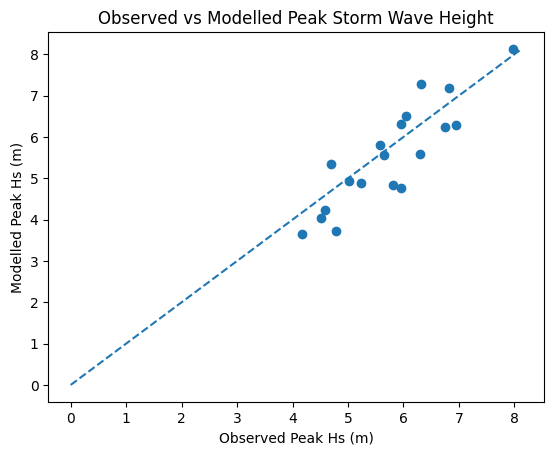

In [14]:
plt.figure()

# Scatter plot
plt.scatter(
    matched_storms["obs_peak_Hs"],
    matched_storms["model_peak_Hs"]
)

# 1:1 reference line
plt.plot(
    [0, max_hs],
    [0, max_hs],
    linestyle="--"
)

plt.xlabel("Observed Peak Hs (m)")
plt.ylabel("Modelled Peak Hs (m)")
plt.title("Observed vs Modelled Peak Storm Wave Height")

plt.show()

# Storm Duration Comparison
Observed vs Modelled Duration

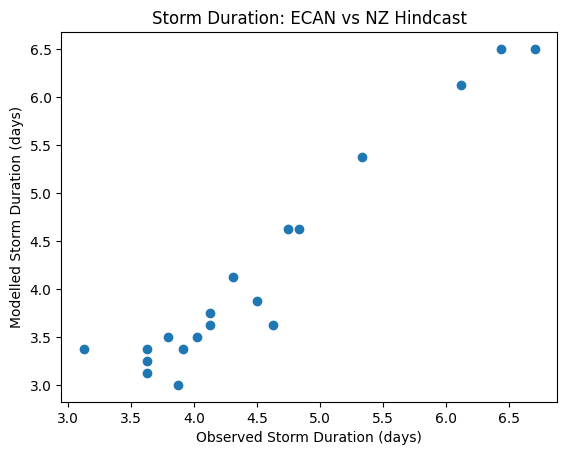

In [15]:
plt.figure()
plt.scatter(
    matched_storms["obs_duration_days"],
    matched_storms["model_duration_days"]
)
plt.xlabel("Observed Storm Duration (days)")
plt.ylabel("Modelled Storm Duration (days)")
plt.title("Storm Duration: ECAN vs NZ Hindcast")
plt.show()

# Timing Error Analysis 
Storm Onset Timing Bias

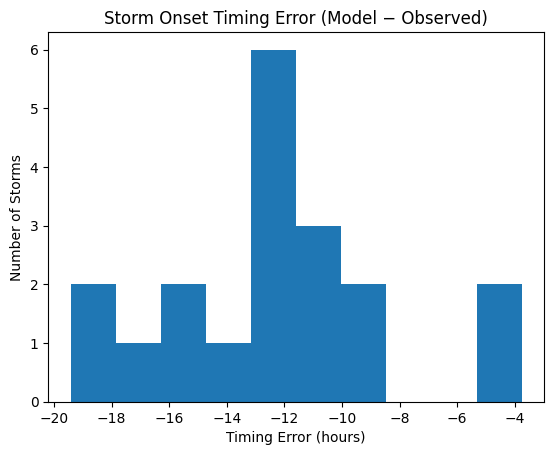

In [16]:
matched_storms["timing_error_hours"] = (
    matched_storms["model_start"] - matched_storms["obs_start"]
).dt.total_seconds() / 3600

plt.figure()
plt.hist(matched_storms["timing_error_hours"])
plt.xlabel("Timing Error (hours)")
plt.ylabel("Number of Storms")
plt.title("Storm Onset Timing Error (Model − Observed)")
plt.show()